In [1]:
import sys
import os
sys.path.append("/home/karlandersson/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/MasterThesisProject/scripts/heatpipe


In [2]:
import json
import matplotlib.pyplot as plt

from utils.heatpipe_utils import generate_cfgs_seq, plot_heatpipe_solutions
from utils.solver import Solver

from coupled.heatpipe import Heatpipe

In [3]:
with open("../../data/vapour_data.json", "r") as f:
    data_guoju = json.load(f)
    data = data_guoju["data_guoju_1000"]

In [6]:
ncfgs = 5
Qs = [1e3 for i in range(ncfgs)]
Ns = [[50, 80] for i in range(len(Qs))]
cfgs = generate_cfgs_seq(data, Ns, Qs)

labels = []

for i in range(ncfgs):
    cfgs[i].material.h_cond += 2*i
    labels.append(r"$h_{cond} = $" + f"{cfgs[i].material.h_cond}")

print(labels)

heatpipes = [Heatpipe(cfg) for cfg in cfgs]

Mesh warning: N_R changed from 50 to 48
Mesh warning: N_Z changed from 80 to 84
Mesh warning: N_R changed from 50 to 48
Mesh warning: N_Z changed from 80 to 84
Mesh warning: N_R changed from 50 to 48
Mesh warning: N_Z changed from 80 to 84
Mesh warning: N_R changed from 50 to 48
Mesh warning: N_Z changed from 80 to 84
Mesh warning: N_R changed from 50 to 48
Mesh warning: N_Z changed from 80 to 84
['$h_{cond} = $62.6', '$h_{cond} = $64.6', '$h_{cond} = $66.6', '$h_{cond} = $68.6', '$h_{cond} = $70.6']


In [7]:
solver = Solver(heatpipes)
solver.fsolve()

Running case 1 ...
Running case 2 ...
Running case 3 ...
Running case 4 ...
Running case 5 ...


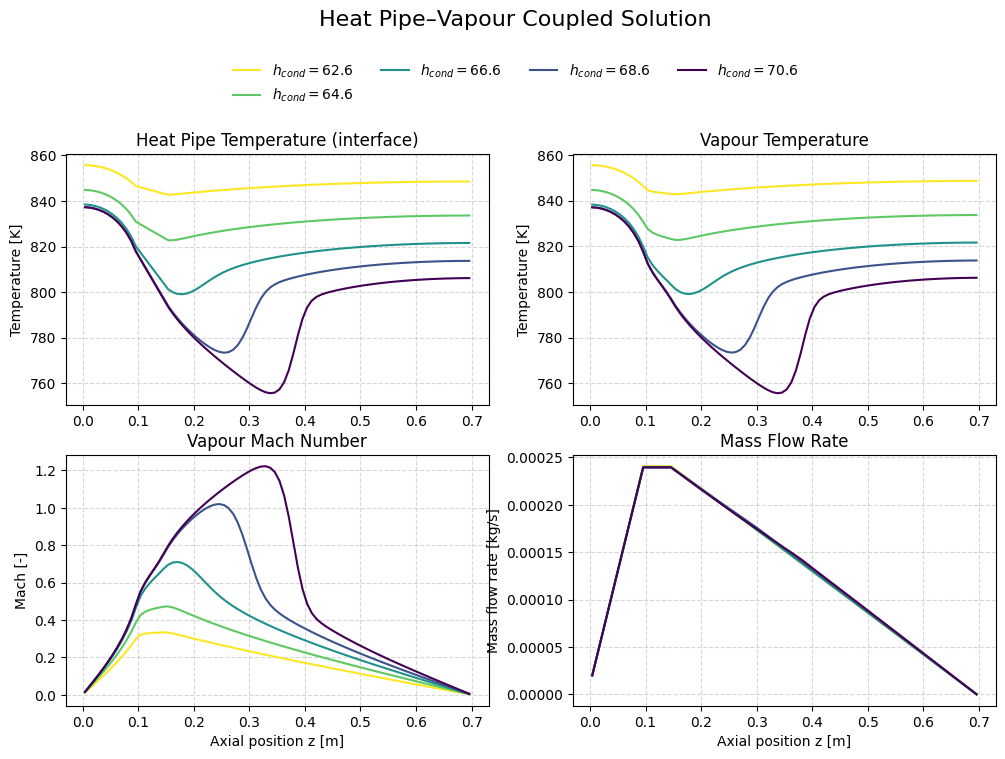

In [8]:
plot_heatpipe_solutions(solver, labels)